In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('data_annonces.csv')

In [6]:
before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c not in ['log_prix_m2', 'log_surface_m2']])
print(f"Doublons supprimés : {before - len(df)}")
print("Shape après déduplication :", df.shape)

Doublons supprimés : 93
Shape après déduplication : (2804, 34)


## 2. Préparation de données

In [7]:
df_encoded = df.copy()
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded['etat'] = df_encoded['etat'].fillna('Bon état')

cible = 'log_prix_m2'
X = df_encoded.drop(columns=[cible, 'prix_m2', 'surface_m2', 'latitude', 'longitude'])
y = df_encoded[cible]

vars_cat = ['quartier', 'type_bien', 'etat']
for c in vars_cat:
    X[c] = X[c].astype(str)
vars_num = [c for c in X.columns if c not in vars_cat]
cat_idx = [X.columns.get_loc(c) for c in vars_cat]

print("Variables catégorielles :", vars_cat)
print("Nombre de variables numériques :", len(vars_num))

Variables catégorielles : ['quartier', 'type_bien', 'etat']
Nombre de variables numériques : 26


## 3. Comparaison des modèles 

In [8]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

preprocessor_linear = ColumnTransformer([
    ('num', StandardScaler(), vars_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), vars_cat)
])
preprocessor_tree = ColumnTransformer([
    ('num', StandardScaler(), vars_num),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), vars_cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

def evalmod(name, model, native=False):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    results.append({'Modèle': name, 'Test R2': r2, 'Test MAPE %': mape})
    print(f"{name:30s}  Test R2 = {r2:.4f}   Test MAPE = {mape:.3f}%")

evalmod('Régression linéaire', Pipeline([('p', preprocessor_linear), ('m', LinearRegression())]))
evalmod('Random Forest', Pipeline([('p', preprocessor_tree), ('m', RandomForestRegressor(random_state=42, n_jobs=-1))]))
evalmod('XGBoost', Pipeline([('p', preprocessor_tree), ('m', XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'))]))
evalmod('LightGBM', Pipeline([('p', preprocessor_tree), ('m', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))]))
evalmod('CatBoost (catégories natives)', CatBoostRegressor(random_state=42, verbose=False, cat_features=cat_idx), native=True)

pd.DataFrame(results)

Régression linéaire             Test R2 = 0.4915   Test MAPE = 1.865%
Random Forest                   Test R2 = 0.4252   Test MAPE = 1.960%
XGBoost                         Test R2 = 0.4647   Test MAPE = 1.876%


c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM                        Test R2 = 0.5137   Test MAPE = 1.798%
CatBoost (catégories natives)   Test R2 = 0.5267   Test MAPE = 1.759%


,Modèle,Test R2,Test MAPE %
0,Régression linéaire,0.491473,1.865337
1,Random Forest,0.425229,1.959715
2,XGBoost,0.464699,1.875863
3,LightGBM,0.513687,1.798248
4,CatBoost (catégories natives),0.526685,1.758798


## 4. Validation croisée : LightGBM et CatBoost

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, build, native in [
    ('LightGBM', lambda: Pipeline([('p', preprocessor_tree), ('m', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))]), False),
    ('CatBoost', lambda: CatBoostRegressor(random_state=42, verbose=False, cat_features=cat_idx), True),
]:
    r2s = []
    for tr_idx, va_idx in kf.split(X):
        m = build()
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = m.predict(X.iloc[va_idx])
        r2s.append(r2_score(y.iloc[va_idx], pred))
    r2s = np.array(r2s)
    print(f"{name:10s}  CV R2 = {r2s.mean():.4f} +/- {r2s.std():.4f}")

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X 

LightGBM    CV R2 = 0.5302 +/- 0.0324
CatBoost    CV R2 = 0.5255 +/- 0.0436


In [12]:
# hyperparamètrage de CatBoost avec Optuna et validation croisée
import optuna   
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 100, log=True),
        'random_state': 42,
        'verbose': False,
        'cat_features': cat_idx
    }
    model = CatBoostRegressor(**params)
    r2s = []
    for tr_idx, va_idx in kf.split(X):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = model.predict(X.iloc[va_idx])
        r2s.append(r2_score(y.iloc[va_idx], pred))
    return np.mean(r2s)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)
print("Best params:", study.best_params)
best_params = study.best_params


[I 2026-06-10 10:15:33,774] A new study created in memory with name: no-name-5d32d87b-0097-4153-9f76-9795e60bd538
[I 2026-06-10 10:16:57,243] Trial 0 finished with value: 0.5425349491820431 and parameters: {'iterations': 847, 'depth': 5, 'learning_rate': 0.109761413677062, 'l2_leaf_reg': 25.75180054790192}. Best is trial 0 with value: 0.5425349491820431.
[I 2026-06-10 10:18:25,752] Trial 1 finished with value: 0.48881100813818285 and parameters: {'iterations': 577, 'depth': 7, 'learning_rate': 0.11171836747900989, 'l2_leaf_reg': 0.0002383985399763793}. Best is trial 0 with value: 0.5425349491820431.
[I 2026-06-10 10:19:33,879] Trial 2 finished with value: 0.5314031426719914 and parameters: {'iterations': 716, 'depth': 5, 'learning_rate': 0.017549988797912117, 'l2_leaf_reg': 0.0007001585993603194}. Best is trial 0 with value: 0.5425349491820431.
[I 2026-06-10 10:22:32,590] Trial 3 finished with value: 0.4635964972119668 and parameters: {'iterations': 416, 'depth': 10, 'learning_rate': 0

Best params: {'iterations': 998, 'depth': 3, 'learning_rate': 0.21188823445847535, 'l2_leaf_reg': 85.0209488118102}


In [14]:
# Catboost avec les meilleurs hyperparamètres
model_catboost = CatBoostRegressor(random_state=42, verbose=False, cat_features=cat_idx, **best_params)
evalmod('CatBoost optimisé', model_catboost)

CatBoost optimisé               Test R2 = 0.5302   Test MAPE = 1.748%


In [15]:
# téléchargement du modèle optimisé
import joblib  
joblib.dump(model_catboost, 'catboost_final_model.pkl')

['catboost_final_model.pkl']

In [10]:
# hyperparamètrage de LightGBM avec Optuna et validation croisée
import optuna
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    model = Pipeline([
        ('p', preprocessor_tree),
        ('m', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **params))
    ])
    r2s = []
    for tr_idx, va_idx in kf.split(X):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = model.predict(X.iloc[va_idx])
        r2s.append(r2_score(y.iloc[va_idx], pred))
    return np.mean(r2s)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)
best_params = study.best_params

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-10 10:03:05,177] A new study created in memory with name: no-name-c2ec513e-6cfb-4caf-95e0-67e10f43bea6
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegress

Best params: {'num_leaves': 54, 'max_depth': 12, 'learning_rate': 0.014250872940364133, 'n_estimators': 739, 'min_child_samples': 50}


In [11]:
# LightGBM avec les meilleurs hyperparamètres
model_lgbm = Pipeline([
    ('p', preprocessor_tree),
    ('m', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **best_params))
]) 
evalmod('LightGBM optimisé', model_lgbm)

LightGBM optimisé               Test R2 = 0.5205   Test MAPE = 1.766%


c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5.Interprétabilité de CatBoost

In [17]:
import shap

# Calcul des valeurs SHAP sur le set de test
explainer = shap.TreeExplainer(model_catboost)
shap_values = explainer.shap_values(X_test)

# on  les exponentie multiplicativement : impact_dh ≈ exp(shap) - 1 sur la prediction.
print(f"Valeurs SHAP calculées : shape = {shap_values.shape}")
print(f"Base value (log)        = {explainer.expected_value:.4f}")
print(f"Base value (DH/m²)      ≈ {np.expm1(explainer.expected_value):.0f}")

Valeurs SHAP calculées : shape = (561, 29)
Base value (log)        = 9.6635
Base value (DH/m²)      ≈ 15732


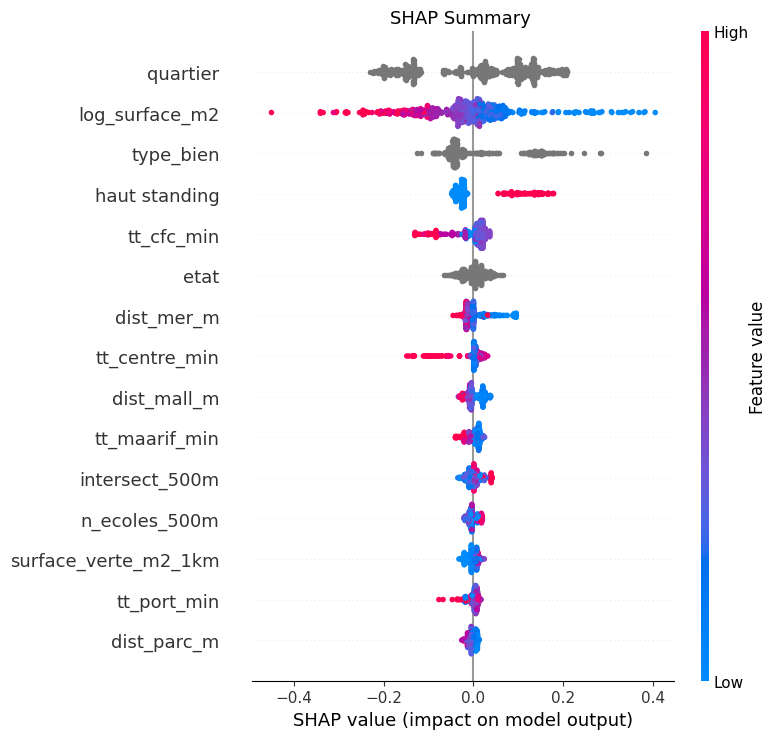

In [20]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Summary ", fontsize=13)
plt.tight_layout()
plt.show()